In [1]:
#%pip install azure-identity azure-storage-blob pandas
#%pip install scikit-learn seaborn matplotlib
#%pip install sqlalchemy pyodbc

In [10]:
# import urllib.request
# ip = urllib.request.urlopen('https://ident.me').read().decode('utf8')
# print(f"My Compute IP is: {ip}")

My Compute IP is: 4.193.227.133


## Load Data

In [2]:
import pandas as pd
import json
from io import BytesIO
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient

from datetime import datetime

# --- 1. ENTERPRISE CONFIGURATION ---
ACCOUNT_URL = "https://rawtradingdata26.blob.core.windows.net"
CONTAINER_NAME = "raw-market-data"

# Dynamically generate today's date string (e.g., '20260401')
today_str = datetime.now().strftime('%Y%m%d')

# Inject the date into the filenames
MARKET_BLOB_NAME = f"market_data_{today_str}.csv"
MACRO_BLOB_NAME = f"macro_data_{today_str}.json"

# Authenticate securely using the workspace's Managed Identity
print("Authenticating with Azure Managed Identity...")
credential = DefaultAzureCredential()
blob_service_client = BlobServiceClient(account_url=ACCOUNT_URL, credential=credential)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# --- 2. LOAD MARKET DATA (CSV) ---
print("Downloading Market Data securely...")
market_blob_client = container_client.get_blob_client(MARKET_BLOB_NAME)
market_download = market_blob_client.download_blob().readall()

df_market = pd.read_csv(BytesIO(market_download), header=[0, 1], index_col=0, parse_dates=True)
print(f"Market Data Loaded: {df_market.shape}")

# --- 3. LOAD MACRO DATA (JSON) ---
print("Downloading Macro Data securely...")
macro_blob_client = container_client.get_blob_client(MACRO_BLOB_NAME)
macro_download = macro_blob_client.download_blob().readall()

macro_json = json.loads(macro_download)
df_macro = pd.DataFrame(macro_json['observations'])

df_macro['date'] = pd.to_datetime(df_macro['date'])
df_macro['value'] = pd.to_numeric(df_macro['value'], errors='coerce')
df_macro = df_macro[['date', 'value']].rename(columns={'value': 'CPI'}).set_index('date')
print(f"Macro Data Loaded: {df_macro.shape}")

# Verify the data
print(df_market.head())

Authenticating with Azure Managed Identity...
Market Data Loaded: (2514, 35)
Macro Data Loaded: (950, 1)
Price            Close                                                         \
Ticker             SPY        XLE        XLF        XLK        XLU        XLV   
Date                                                                            
2016-04-01  175.797073  20.351555  15.296230  20.045519  18.117249  58.006634   
2016-04-04  175.227890  20.201572  15.222114  19.969278  18.040863  58.700527   
2016-04-05  173.477676  20.064922  15.006481  19.776449  17.702597  57.938927   
2016-04-06  175.372253  20.498215  15.087343  19.969278  17.680779  59.495934   
2016-04-07  173.273758  20.378225  14.804328  19.682276  17.673508  58.844379   

Price                        High                        ...       Open  \
Ticker            XLY         SPY        XLE        XLF  ...        XLU   
Date                                                     ...              
2016-04-01  35.737534

## Clean, Align, Scaling and Clustering

Cleaned ML Dataset Shape: (2430, 38)


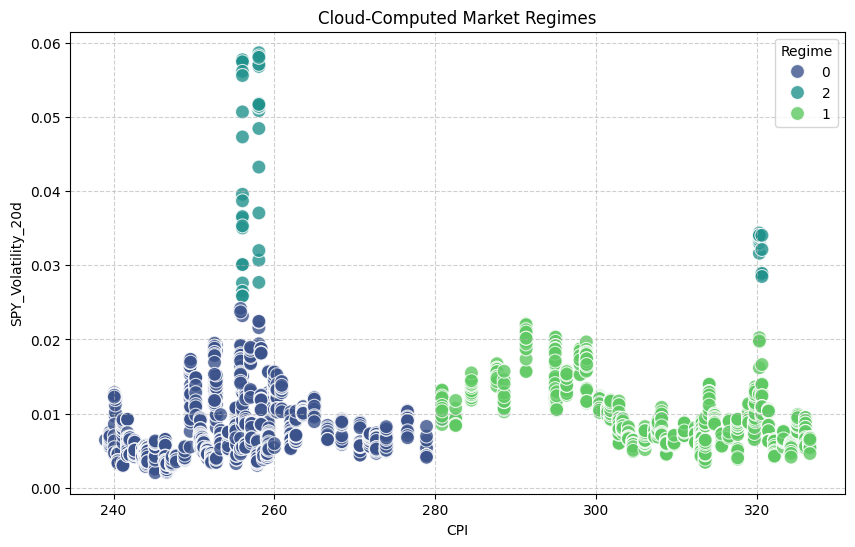


--- Cloud Cluster Averages ---
        SPY_Daily_Return  SPY_Volatility_20d         CPI
Regime                                                  
0               0.000704            0.007775  254.078597
1               0.000373            0.009797  307.516986
2               0.002802            0.040452  279.220386


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CLEAN & ALIGN ---
# THE FIX: Only flatten if it's a MultiIndex (prevents the double-run notebook bug!)
if isinstance(df_market.columns, pd.MultiIndex):
    df_market.columns = [f"{col[0]}_{col[1]}" for col in df_market.columns.values]

# Patch any random missing days in the Yahoo Finance data
df_market = df_market.ffill()

# Strip timezones from the market data index so it matches the macro data
if df_market.index.tz is not None:
    df_market.index = df_market.index.tz_localize(None)

# Expand the monthly CPI data to every single calendar day BEFORE joining
df_macro_daily = df_macro.resample('D').ffill()

# Now perform the join safely
df_merged = df_market.join(df_macro_daily, how='left')

# --- 2. FEATURE ENGINEERING ---
df_merged['SPY_Daily_Return'] = df_merged['Close_SPY'].pct_change()
df_merged['SPY_Volatility_20d'] = df_merged['SPY_Daily_Return'].rolling(window=20).std()

# Only drop rows if our critical Machine Learning features are missing!
features = ['SPY_Daily_Return', 'SPY_Volatility_20d', 'CPI']
df_cleaned = df_merged.dropna(subset=features).copy()

print(f"Cleaned ML Dataset Shape: {df_cleaned.shape}")

# --- 3. SCALING & CLUSTERING ---
features = ['SPY_Daily_Return', 'SPY_Volatility_20d', 'CPI']
X = df_cleaned[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['Regime'] = kmeans.fit_predict(X_scaled).astype(str)

# --- 4. VISUALIZE ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='CPI', y='SPY_Volatility_20d', hue='Regime', palette='viridis', s=100, alpha=0.8)
plt.title('Cloud-Computed Market Regimes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Cloud Cluster Averages ---")
print(df_cleaned.groupby('Regime')[features].mean())

## Upload Structured Data

In [8]:
import pandas as pd
import urllib
from sqlalchemy import create_engine

print("--- SAVING STRUCTURED DATA TO AZURE SQL (ENTRA ID) ---")

# 1. SQL Server Config
server = 'quant-server-123.database.windows.net' 
database = 'trading-db'
driver = '{ODBC Driver 17 for SQL Server}'

# 2. Build the Passwordless Connection String
# THE FIX: Added 'tcp:', embedded the port, and added Azure's required Encryption flags
odbc_str = f'DRIVER={driver};SERVER=tcp:{server},1433;DATABASE={database};Authentication=ActiveDirectoryMsi;Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;'
connect_str = 'mssql+pyodbc:///?odbc_connect=' + urllib.parse.quote_plus(odbc_str)

# We add fast_executemany=True to speed up the dataframe upload
engine = create_engine(connect_str, fast_executemany=True)

# 3. Write the Cleaned & Clustered DataFrame to SQL
df_sql = df_cleaned.reset_index()

try:
    print("Writing feature-engineered data to SQL Database...")
    df_sql.to_sql('ProcessedMarketData', engine, if_exists='replace', index=False)
    print("✅ Successfully saved structured data to Azure SQL Database without passwords!")
    
    latest_regime = df_sql.iloc[-1]['Regime']
    print(f"Today's AI Classification: Regime {latest_regime}")
    
except Exception as e:
    print(f"❌ Failed to upload to SQL: {e}")

--- SAVING STRUCTURED DATA TO AZURE SQL (ENTRA ID) ---
Writing feature-engineered data to SQL Database...
❌ Failed to upload to SQL: (pyodbc.OperationalError) ('HYT00', '[HYT00] [Microsoft][ODBC Driver 17 for SQL Server]Login timeout expired (0) (SQLDriverConnect)')
(Background on this error at: https://sqlalche.me/e/20/e3q8)


## Dynamic Back-test Code

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EVALUATING COMPREHENSIVE SECTOR ROTATION STRATEGY ---")

# THE FIX: Drop any columns that completely failed to download from Yahoo Finance
df_cleaned = df_cleaned.dropna(axis=1, how='all')

# 1. Dynamically find all valid asset columns that survived
price_columns = [col for col in df_cleaned.columns if col.startswith('Close_')]
assets = [col.split('_')[1] for col in price_columns]

# 2. Calculate Forward Returns for ALL valid assets in a loop
return_columns = []
for asset in assets:
    col_name = f'{asset}_Fwd_Return'
    df_cleaned[col_name] = df_cleaned[f'Close_{asset}'].pct_change().shift(-1)
    return_columns.append(col_name)

# THE FIX: Only drop rows where the *Returns* are missing (safely drops the final unknown day)
backtest_df = df_cleaned.dropna(subset=return_columns)

# 3. Group by Regime and calculate annualized returns
regime_performance = backtest_df.groupby('Regime')[return_columns].mean()
annualized_performance = regime_performance * 252 * 100 

# Clean up column names for the chart
annualized_performance.columns = assets

print("\n📈 Annualized Expected Return by Regime (%)")
display(annualized_performance.round(2))

# 4. Visualize the Comprehensive Rotation
plt.figure(figsize=(14, 7))
annualized_performance.plot(kind='bar', figsize=(14, 7), colormap='tab10', edgecolor='black')

plt.title('Strategy Evaluation: Comprehensive Sector Performance by AI Market Regime', fontsize=14, fontweight='bold')
plt.ylabel('Annualized Expected Return (%)', fontsize=12)
plt.xlabel('AI Identified Regime', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend(title='Sectors / Baseline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

--- EVALUATING COMPREHENSIVE SECTOR ROTATION STRATEGY ---

📈 Annualized Expected Return by Regime (%)


,SPY,XLE,XLF,XLK,XLU,XLV,XLY
Regime,,,,,,,
0,15.94,1.63,16.14,26.15,12.04,12.64,17.71
1,13.36,23.79,11.59,16.75,10.12,8.15,8.50
2,57.68,93.00,54.16,101.88,6.39,35.85,69.09


<Figure size 1400x700 with 0 Axes>